# CRPSLoss & Probabilistic Forecasting

This notebook explains how to use `CRPSLoss` in BaseAttentive for
full-distribution probabilistic forecasting — going beyond point estimates
and simple quantile intervals.

## What is CRPS?

The **Continuous Ranked Probability Score (CRPS)** is a proper scoring
rule that measures how well a predicted probability distribution matches
the observed value.  Unlike:

- **MSE / MAE** — only score a single point prediction,
- **Pinball / quantile loss** — scores individual quantile levels separately,

CRPS rewards *calibrated* distributions that are both sharp (narrow) and
centred on the truth.  It collapses to MAE for a deterministic forecast.

$$
\text{CRPS}(F, y) = \int_{-\infty}^{\infty} \left(F(z) - \mathbf{1}[z \geq y]\right)^2 dz
$$

## Three Modes in BaseAttentive

| Mode | How it works | Best for |
|------|-------------|----------|
| `"quantile"` | Pinball loss averaged over user-specified quantile levels | Any output head; fast |
| `"gaussian"` | Closed-form CRPS for a single Gaussian predictive distribution | Unimodal, near-Gaussian targets |
| `"mixture"` | Monte-Carlo CRPS estimate from a Gaussian mixture | Multi-modal / heavy-tailed targets |

## Setup

In [1]:
import matplotlib.pyplot as plt
import os

import numpy as np

# ── v2.2.0 Backend Setup ─────────────────────────────────────────────────────
# BASE_ATTENTIVE_BACKEND must be set *before* importing base_attentive.
# Choose your installed backend: "tensorflow" | "torch" | "jax" | "auto"
os.environ.setdefault("BASE_ATTENTIVE_BACKEND", "tensorflow")
os.environ.setdefault("KERAS_BACKEND", os.environ["BASE_ATTENTIVE_BACKEND"])
import keras  # initialise Keras 3 backend before base_attentive
BACKEND = os.environ["BASE_ATTENTIVE_BACKEND"]

from base_attentive import BaseAttentive, __version__
from base_attentive.components.heads import (
    GaussianHead,
    MixtureDensityHead,
)
from base_attentive.components.losses import CRPSLoss

print(f"BaseAttentive {__version__} — backend: {BACKEND}")

BaseAttentive 2.2.0 — backend: tensorflow


## Synthetic Dataset

We create a small dataset with three distinct input streams (static,
dynamic, future) and a two-dimensional forecast target.

In [2]:
# Synthetic dataset: structured daily-cycle signals with controlled noise
# Using patterns makes probabilistic forecasting results interpretable.
BATCH = 128
LOOKBACK = 24
HORIZON  = 12
STATIC_DIM  = 4
DYN_DIM     = 8
FUT_DIM     = 4
OUTPUT_DIM  = 2

rng = np.random.default_rng(42)

# Daily sine-wave base pattern
t_hist = np.linspace(0, 4*np.pi, LOOKBACK)
t_fut  = np.linspace(4*np.pi, 6*np.pi, HORIZON)
base_past   = np.sin(t_hist)
base_future = np.sin(t_fut)

# Static + dynamic + future inputs
x_static  = rng.standard_normal((BATCH, STATIC_DIM)).astype('float32')
x_dynamic = np.zeros((BATCH, LOOKBACK, DYN_DIM), dtype='float32')
for d in range(DYN_DIM):
    x_dynamic[:,:,d] = (np.tile(np.sin(t_hist*(1+d*0.1)), (BATCH,1))
                        + 0.15*rng.standard_normal((BATCH,LOOKBACK)))
x_future  = rng.standard_normal((BATCH, HORIZON, FUT_DIM)).astype('float32')

# Target: sine wave + moderate noise (unimodal -- good for quantile/gaussian)
y_true = np.stack([
    np.tile(base_future, (BATCH,1)) + 0.25*rng.standard_normal((BATCH,HORIZON)),
    np.tile(base_future*(1.2), (BATCH,1)) + 0.3*rng.standard_normal((BATCH,HORIZON)),
], axis=-1).astype('float32')

# Bimodal target for mixture mode: two regimes separated by +/-0.6
regime = rng.integers(0, 2, size=(BATCH, HORIZON))
shift  = np.where(regime, +0.6, -0.6)
y_bimodal = np.stack([
    np.tile(base_future, (BATCH,1)) + shift + 0.1*rng.standard_normal((BATCH,HORIZON)),
    np.tile(base_future, (BATCH,1)) + shift + 0.1*rng.standard_normal((BATCH,HORIZON)),
], axis=-1).astype('float32')

print('x_static :', x_static.shape)
print('x_dynamic:', x_dynamic.shape)
print('x_future :', x_future.shape)
print('y_true   :', y_true.shape,  ' (unimodal, for quantile/gaussian)')
print('y_bimodal:', y_bimodal.shape,' (bimodal regime, for mixture)')

steps = np.arange(1, HORIZON + 1)


x_static : (128, 4)
x_dynamic: (128, 24, 8)
x_future : (128, 12, 4)
y_true   : (128, 12, 2)  (unimodal, for quantile/gaussian)
y_bimodal: (128, 12, 2)  (bimodal regime, for mixture)


---

## Mode 1 — `"quantile"` (Pinball Loss)

The `quantile` mode computes the **pinball loss** (also called the
quantile loss or check function) for every quantile level you specify,
then averages across levels and all other dimensions.

### Build a quantile model

Pass `quantiles` to `BaseAttentive`; the output shape becomes
`(batch, horizon, n_quantiles, output_dim)`.

In [3]:
import keras

QUANTILES = [0.1, 0.25, 0.5, 0.75, 0.9]

model_q = BaseAttentive(
    static_input_dim=STATIC_DIM,
    dynamic_input_dim=DYN_DIM,
    future_input_dim=FUT_DIM,
    output_dim=OUTPUT_DIM,
    forecast_horizon=HORIZON,
    quantiles=QUANTILES,
    embed_dim=32,
    num_heads=4,
    dropout_rate=0.1,
    name='QuantileModel',
)
preds_q = model_q([x_static, x_dynamic, x_future])
print('Quantile output shape:', preds_q.shape)
# Expected: (128, 12, 5, 2) -- batch, horizon, quantiles, output_dim

crps_q = CRPSLoss(mode='quantile', quantiles=QUANTILES)
_ = model_q([x_static, x_dynamic, x_future])  # build weights
model_q.compile(optimizer=keras.optimizers.Adam(1e-3), loss=crps_q)
print('Training quantile model (15 epochs)...')
history_q = model_q.fit(
    x=[x_static, x_dynamic, x_future], y=y_true,
    epochs=15, batch_size=16, validation_split=0.2, verbose=0,
)
print(f'  Final train CRPS: {history_q.history["loss"][-1]:.4f}  '
      f'val CRPS: {history_q.history["val_loss"][-1]:.4f}')


D:\projects\base-attentive\src\base_attentive\core\base_attentive.py:148: DeprecatedParameterWarning: BaseAttentive: 'static_input_dim' is deprecated since 2.1.0 and will be removed in 3.0.0. Use 'static_dim' instead.
  resolved = resolve_deprecated_kwargs(
D:\projects\base-attentive\src\base_attentive\core\base_attentive.py:148: DeprecatedParameterWarning: BaseAttentive: 'dynamic_input_dim' is deprecated since 2.1.0 and will be removed in 3.0.0. Use 'dynamic_dim' instead.
  resolved = resolve_deprecated_kwargs(
D:\projects\base-attentive\src\base_attentive\core\base_attentive.py:148: DeprecatedParameterWarning: BaseAttentive: 'future_input_dim' is deprecated since 2.1.0 and will be removed in 3.0.0. Use 'future_dim' instead.
  resolved = resolve_deprecated_kwargs(


Quantile output shape: (128, 12, 5, 2)
Training quantile model (15 epochs)...
  Final train CRPS: 0.0936  val CRPS: 0.0940


### Reading quantile predictions

The output layout is `(batch, horizon, n_quantiles, output_dim)`.  To
extract the median (index 2 for the 0.5 quantile above):

In [4]:
import numpy as np

preds_np = np.array(model_q([x_static, x_dynamic, x_future]))
# preds_np shape: (BATCH, HORIZON, N_QUANTILES, OUTPUT_DIM)

median_idx = QUANTILES.index(0.5)
lower_idx  = QUANTILES.index(0.1)
q25_idx    = QUANTILES.index(0.25)
q75_idx    = QUANTILES.index(0.75)
upper_idx  = QUANTILES.index(0.9)

median_pred  = preds_np[:, :, median_idx, :]   # (128, 12, 2)
lower_bound  = preds_np[:, :, lower_idx,  :]   # (128, 12, 2)
q25_bound    = preds_np[:, :, q25_idx,    :]
q75_bound    = preds_np[:, :, q75_idx,    :]
upper_bound  = preds_np[:, :, upper_idx,  :]   # (128, 12, 2)

interval_width_80 = upper_bound - lower_bound
print('Median prediction shape:', median_pred.shape)
print('80% PI mean width:', interval_width_80.mean().round(4))


Median prediction shape: (128, 12, 2)
80% PI mean width: 0.4101


---

## Mode 2 — `gaussian` via `GaussianHead`

BaseAttentive v2.1.0 keeps the core model focused on **point** and
**quantile** forecasting. For Gaussian CRPS workflows, attach a
`GaussianHead` to any latent feature tensor produced by your own
backbone or preprocessing pipeline.

Here we use a synthetic latent feature tensor with shape
`(batch, horizon, feature_dim)`.


In [5]:
# Build a small Keras model to produce latent features from our inputs
FEATURE_DIM = 16
# Use a simple dense projection to get latent features
latent_inp  = keras.Input(shape=(HORIZON, DYN_DIM), name='dyn_inp')
latent_proj = keras.layers.Dense(FEATURE_DIM, activation='relu')(latent_inp)
latent_model = keras.Model(latent_inp, latent_proj, name='latent_encoder')
# Extract latent features from dynamic input (first HORIZON steps)
latent_features = np.array(
    latent_model(x_dynamic[:, :HORIZON, :DYN_DIM].astype('float32'))
).astype('float32')

gaussian_head = GaussianHead(output_dim=OUTPUT_DIM)
gaussian_raw  = gaussian_head(latent_features)
y_pred_g = {'loc': gaussian_raw['mean'], 'scale': gaussian_raw['scale']}

print('Gaussian loc   shape:', y_pred_g['loc'].shape)
print('Gaussian scale shape:', y_pred_g['scale'].shape)


Gaussian loc   shape: (128, 12, 2)
Gaussian scale shape: (128, 12, 2)


In [6]:
crps_g = CRPSLoss(mode='gaussian')
loss_g = crps_g(y_true, y_pred_g)
crps_g_val = float(np.array(loss_g))
print(f'Gaussian CRPS: {crps_g_val:.4f}')

loc_np   = np.array(y_pred_g['loc'])
sigma_np = np.array(y_pred_g['scale'])
print('Mean  shape:', loc_np.shape)
print('Sigma shape:', sigma_np.shape)
print('Mean sigma (sample 0, step 0):', sigma_np[0, 0].round(4))


Gaussian CRPS: 0.6212
Mean  shape: (128, 12, 2)
Sigma shape: (128, 12, 2)
Mean sigma (sample 0, step 0): [0.6906 0.7008]


### Inspecting mean and standard deviation


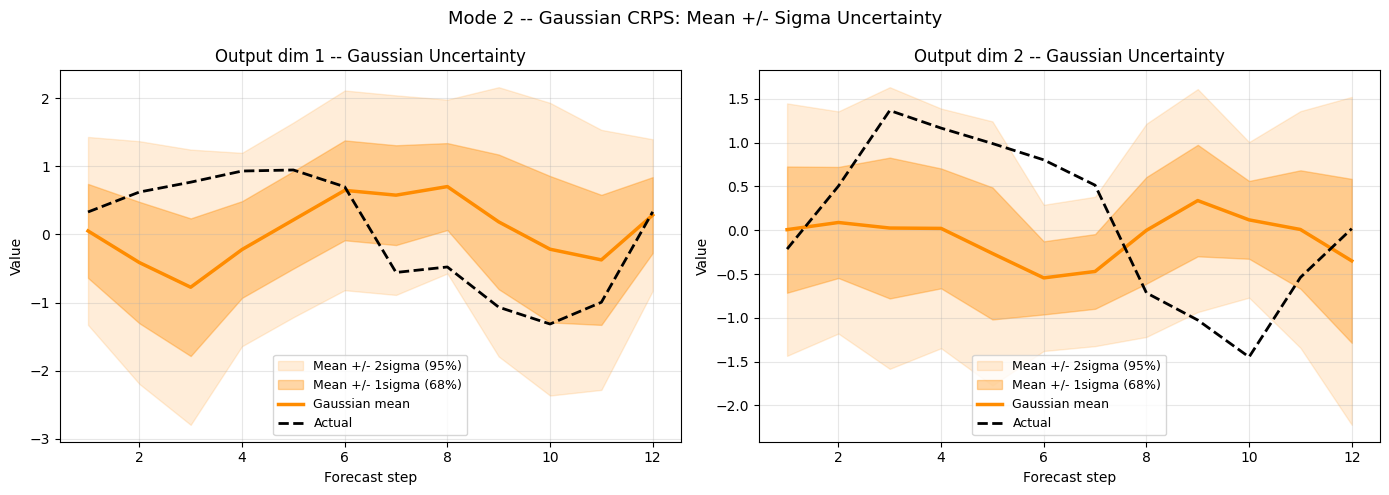

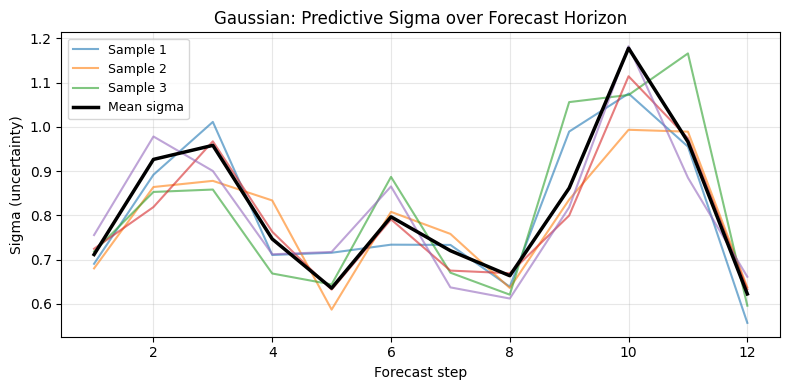

In [7]:
# Gaussian uncertainty bands: mean +/- 1sigma and +/- 2sigma
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for d, ax in enumerate(axes):
    s = d
    mu  = loc_np[s, :, d]
    sig = sigma_np[s, :, d]

    ax.fill_between(steps, mu-2*sig, mu+2*sig,
                    alpha=0.15, color='darkorange', label=r'Mean +/- 2sigma (95%)')
    ax.fill_between(steps, mu-sig,   mu+sig,
                    alpha=0.35, color='darkorange', label=r'Mean +/- 1sigma (68%)')
    ax.plot(steps, mu,              color='darkorange', lw=2.5, label='Gaussian mean')
    ax.plot(steps, y_true[s,:,d],   color='black',      lw=2, linestyle='--',
            label='Actual', zorder=5)
    ax.set_title(f'Output dim {d+1} -- Gaussian Uncertainty', fontsize=12)
    ax.set_xlabel('Forecast step'); ax.set_ylabel('Value')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle('Mode 2 -- Gaussian CRPS: Mean +/- Sigma Uncertainty', fontsize=13)
plt.tight_layout(); plt.show()

# Sigma growth over horizon
fig, ax = plt.subplots(figsize=(8, 4))
for samp in range(min(5, BATCH)):
    ax.plot(steps, sigma_np[samp,:,0], alpha=0.6, lw=1.5,
            label=f'Sample {samp+1}' if samp < 3 else '')
ax.plot(steps, sigma_np[:,:,0].mean(0), color='black', lw=2.5, label='Mean sigma')
ax.set_title('Gaussian: Predictive Sigma over Forecast Horizon', fontsize=12)
ax.set_xlabel('Forecast step'); ax.set_ylabel('Sigma (uncertainty)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


---

## Mode 3 — `mixture` via `MixtureDensityHead`

For multi-modal predictive distributions, use `MixtureDensityHead` and
pass its outputs to `CRPSLoss(mode="mixture")`. The head predicts:

- component weights — shape `(B, H, K, D)`
- component means — shape `(B, H, K, D)`
- component scales — shape `(B, H, K, D)`

This is useful when the target distribution may have multiple plausible
future states.


In [8]:
N_COMPONENTS = 3

mixture_head = MixtureDensityHead(output_dim=1, num_components=N_COMPONENTS)  # dim=1 for CRPS compat
mixture_raw  = mixture_head(latent_features)
y_pred_m = {
    'loc':     mixture_raw['means'],
    'scale':   mixture_raw['scales'],
    'weights': mixture_raw['weights'],
}
print('Mixture loc     shape:', y_pred_m['loc'].shape)
print('Mixture scale   shape:', y_pred_m['scale'].shape)
print('Mixture weights shape:', y_pred_m['weights'].shape)


Mixture loc     shape: (128, 12, 3, 1)
Mixture scale   shape: (128, 12, 3, 1)
Mixture weights shape: (128, 12, 3, 1)


In [9]:
crps_m     = CRPSLoss(mode='mixture', mc_samples=128)
loss_m     = crps_m(y_bimodal[:,:,0:1], y_pred_m)
crps_m_val = float(np.array(loss_m))
print(f'Mixture CRPS (128 samples): {crps_m_val:.4f}')


Mixture CRPS (128 samples): 0.5780


### Mixture Density — Distribution per Forecast Step

C:\Users\Daniel\AppData\Local\Temp\ipykernel_7868\3746217335.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10')


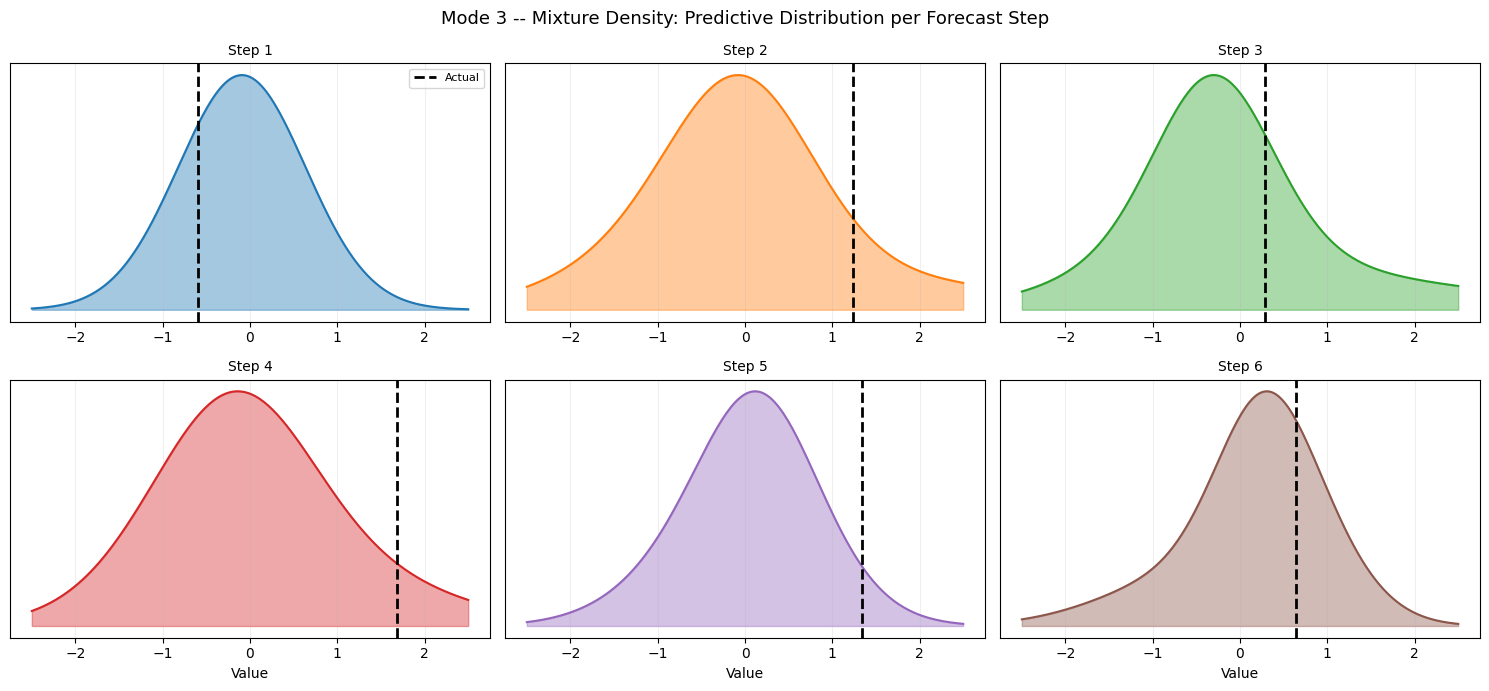

In [10]:
# Mixture density visualization: plot the GMM density at each step
import matplotlib.pyplot as plt
import matplotlib.cm as cm

means_np   = np.array(y_pred_m['loc'])     # (B, H, K, D)
scales_np  = np.array(y_pred_m['scale'])   # (B, H, K, D)
weights_np = np.array(y_pred_m['weights']) # (B, H, K, D)

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
z_grid = np.linspace(-2.5, 2.5, 200)
cmap = cm.get_cmap('tab10')

for step_i, ax in enumerate(axes.ravel()):
    if step_i >= HORIZON: ax.axis('off'); continue
    s, d = 0, 0  # sample 0, output dim 0
    # Sum of weighted Gaussian densities
    density = np.zeros_like(z_grid)
    for k in range(N_COMPONENTS):
        mu_k  = means_np[s, step_i, k, d]
        sig_k = scales_np[s, step_i, k, d]
        w_k   = weights_np[s, step_i, k, d]
        from scipy.stats import norm as scipy_norm
        density += w_k * scipy_norm.pdf(z_grid, mu_k, sig_k)
    ax.fill_between(z_grid, density, alpha=0.4, color=cmap(step_i % 10))
    ax.plot(z_grid, density, color=cmap(step_i % 10), lw=1.5)
    ax.axvline(y_bimodal[s, step_i, d], color='black', lw=2, linestyle='--',
               label='Actual' if step_i==0 else '')
    ax.set_title(f'Step {step_i+1}', fontsize=10)
    ax.set_xlabel('Value') if step_i >= 3 else None
    ax.set_yticks([]); ax.grid(True, alpha=0.2)
    if step_i == 0: ax.legend(fontsize=8)

plt.suptitle('Mode 3 -- Mixture Density: Predictive Distribution per Forecast Step',
             fontsize=13)
plt.tight_layout(); plt.show()


---

## Comparing the Three Modes

| | `quantile` | `gaussian` | `mixture` |
|-|-----------|-----------|----------|
| **How it is used in v2.2.0** | Directly in `BaseAttentive` | Via `GaussianHead` | Via `MixtureDensityHead` |
| **Distribution shape** | Any (implicit) | Unimodal | Multi-modal |
| **Computation** | Pinball sum | Closed-form | Monte Carlo |
| **Output layout** | `(B, H, Q, O)` | dict with `loc`, `scale` | dict with `loc`, `scale`, `weights` |
| **Training speed** | Fast | Fast | Slower (MC samples) |
| **Calibration** | Quantile-level | Gaussian assumption | Flexible |


## Choosing `mc_samples`

Higher `mc_samples` gives a lower-variance CRPS estimate but increases
memory and compute.  Typical values:

| Situation | Recommended |
|-----------|-------------|
| Quick experiment | 32–64 |
| Production training | 128–256 |
| Final evaluation | 512–1024 |

In [11]:
crps_eval = CRPSLoss(mode='mixture', mc_samples=512)
eval_loss  = crps_eval(y_bimodal[:,:,0:1], y_pred_m)
crps_m_512 = float(np.array(eval_loss))
print(f'Mixture CRPS (512 samples): {crps_m_512:.6f}')
print(f'Mixture CRPS (128 samples): {crps_m_val:.6f}')
print(f'Estimation variance: {abs(crps_m_val - crps_m_512):.6f}')


Mixture CRPS (512 samples): 0.572632
Mixture CRPS (128 samples): 0.577977
Estimation variance: 0.005345


## Custom Training Loop with CRPSLoss

For maximum control (e.g., gradient clipping, custom schedulers) you
can call `CRPSLoss` directly inside a `GradientTape`:

## All-Modes Comparison & CRPS Summary

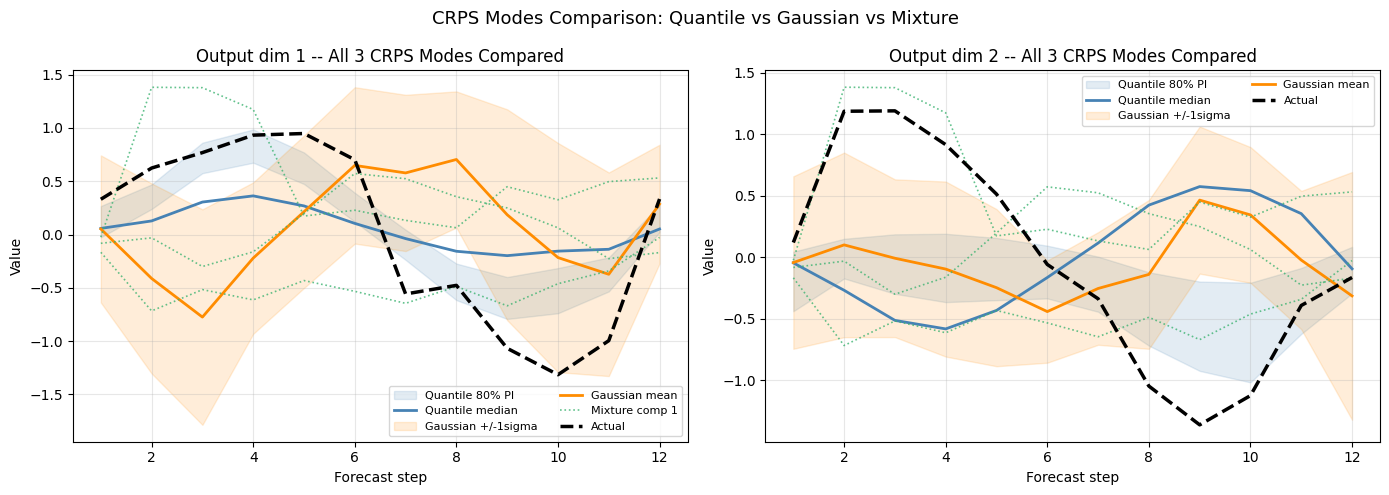

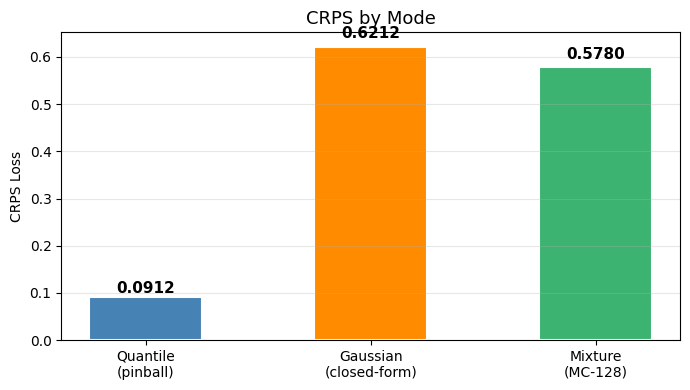

In [12]:
# Overlay all 3 mode predictions on the same sample
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for d, ax in enumerate(axes):
    s = 0
    # Quantile fan
    ax.fill_between(steps,
                    lower_bound[s,:,d], upper_bound[s,:,d],
                    alpha=0.15, color='steelblue', label='Quantile 80% PI')
    ax.plot(steps, median_pred[s,:,d],
            color='steelblue',  lw=2, label='Quantile median')
    # Gaussian bands
    ax.fill_between(steps,
                    loc_np[s,:,d]-sigma_np[s,:,d],
                    loc_np[s,:,d]+sigma_np[s,:,d],
                    alpha=0.15, color='darkorange', label='Gaussian +/-1sigma')
    ax.plot(steps, loc_np[s,:,d],
            color='darkorange',  lw=2, label='Gaussian mean')
    # Mixture component means
    d_m = min(d, means_np.shape[3]-1)  # mixture may have output_dim=1
    for k in range(N_COMPONENTS):
        ax.plot(steps, means_np[s,:,k,d_m],
                color='mediumseagreen', lw=1.2, linestyle=':',
                alpha=0.8, label=f'Mixture comp {k+1}' if d==0 and k==0 else '')
    # Actual
    ax.plot(steps, y_true[s,:,d],
            color='black', lw=2.5, linestyle='--', label='Actual', zorder=6)
    ax.set_title(f'Output dim {d+1} -- All 3 CRPS Modes Compared', fontsize=12)
    ax.set_xlabel('Forecast step'); ax.set_ylabel('Value')
    ax.legend(fontsize=8, ncol=2); ax.grid(True, alpha=0.3)

plt.suptitle('CRPS Modes Comparison: Quantile vs Gaussian vs Mixture', fontsize=13)
plt.tight_layout(); plt.show()

# CRPS summary bar chart
crps_quantile_eval = float(np.array(CRPSLoss(mode='quantile', quantiles=QUANTILES)(y_true, np.array(model_q([x_static, x_dynamic, x_future])))))
crps_gauss_eval    = crps_g_val
crps_mix_eval      = crps_m_val

fig, ax = plt.subplots(figsize=(7, 4))
labels = ['Quantile\n(pinball)', 'Gaussian\n(closed-form)', 'Mixture\n(MC-128)']
values = [crps_quantile_eval, crps_gauss_eval, crps_mix_eval]
colors = ['steelblue', 'darkorange', 'mediumseagreen']
bars = ax.bar(labels, values, color=colors, width=0.5, edgecolor='white', lw=1.5)
for bar, v in zip(bars, values):
    ax.text(bar.get_x()+bar.get_width()/2, v*1.02, f'{v:.4f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('CRPS by Mode', fontsize=13)
ax.set_ylabel('CRPS Loss'); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


---

## Next Steps

- [07_v2_spec_registry.ipynb](07_v2_spec_registry.ipynb) — declarative `BaseAttentiveSpec` and custom component registration
- [05_kernel_robust_networks.ipynb](05_kernel_robust_networks.ipynb) — kernel-robust training strategies
- [Full documentation](https://base-attentive.readthedocs.io/)
- [API reference: CRPSLoss](https://base-attentive.readthedocs.io/en/latest/api_reference.html)